In [1]:
import torch
import torch.nn as nn
import tiktoken

In [2]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

In [3]:
class DummyLayerNorm(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()

  def forward(self, x):
    return x

class DummyTransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()

  def forward(self, x):
    return x

class DummyGPTModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.token_embedding = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_embedding = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    self.layer_norm = DummyLayerNorm(cfg["emb_dim"])
    self.transformer_blocks = nn.Sequential(
        *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
    )
    self.dropout = nn.Dropout(cfg["drop_rate"])
    self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=cfg["qkv_bias"])

  def forward(self, x):
    # x.shape [B, T]
    B, T = x.shape
    token_embd = self.token_embedding(x) # [B, T, E]  E -> emb_dim
    pos_embd = self.token_embedding(torch.arange(0, T)) # [T, E]
    x = token_embd + pos_embd # [T, E] broadcasted to [B, T, E] and then add
    x = self.dropout(x)
    x = self.transformer_blocks(x)
    x = self.layer_norm(x)
    x = self.out_head(x)
    return x


In [4]:
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1))) # [6109, 3626, 6100, 345]
batch.append(torch.tensor(tokenizer.encode(txt2))) # [6109, 1110, 6622, 257]

input = torch.stack(batch, dim=0)
input, input.shape

(tensor([[6109, 3626, 6100,  345],
         [6109, 1110, 6622,  257]]),
 torch.Size([2, 4]))

In [5]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(input)
logits.shape, logits

(torch.Size([2, 4, 50257]),
 tensor([[[-1.0750,  0.4304,  0.5040,  ..., -0.9578, -0.6356, -1.3199],
          [ 0.5017,  0.2335,  0.4686,  ..., -0.3153,  1.0645,  0.7218],
          [ 0.7279,  1.4824, -1.5863,  ...,  0.0709, -0.1961,  1.7649],
          [-0.9319,  0.3951, -0.2767,  ...,  0.4584, -0.7058, -1.5690]],
 
         [[-0.6357,  0.2228,  0.1787,  ..., -1.1135,  0.0585, -1.2404],
          [-0.0847, -0.0223,  0.5116,  ..., -0.3585, -0.4808,  1.6149],
          [ 0.1138,  1.0945, -1.0442,  ..., -1.4982,  0.2043,  1.5221],
          [-0.9886, -2.1791,  0.1054,  ...,  1.3685, -1.4387, -0.1183]]],
        grad_fn=<UnsafeViewBackward0>))

### LayerNorm Implementation

In [6]:
torch.manual_seed(123)
batch_example = torch.randn(2, 5)
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
out = layer(batch_example)
out

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)

In [7]:
# BEFORE NORM
mean = out.mean(dim=1, keepdim=True)
var = out.var(dim=1, keepdim=True)
print(f"BEFORE \n Mean: {mean} \n Var: {var}")

# AFTER NORM:
out_norm = (out-mean)/torch.sqrt(var)
mean = out_norm.mean(dim=1, keepdim=True)
var = out_norm.var(dim=1, keepdim=True)
print(f"AFTER \n Mean: {mean} \n Var: {var}")

BEFORE 
 Mean: tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>) 
 Var: tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)
AFTER 
 Mean: tensor([[9.9341e-09],
        [1.9868e-08]], grad_fn=<MeanBackward1>) 
 Var: tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [8]:
class LayerNorm(nn.Module):
  def __init__(self, emb_dim, eps=1e-5):
    super().__init__()
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))
    self.eps = eps

  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False) # divide by n here to be consistent with what was used in GPT2
    x = (x-mean)/torch.sqrt(var + self.eps)
    x = x*self.scale + self.shift
    return x

In [9]:
layer_norm = LayerNorm(emb_dim=5)
out = layer_norm(batch_example)
out, out.mean(dim=-1, keepdim=True), out.var(dim=-1, keepdim=True, unbiased=False),

(tensor([[ 0.5528,  1.0693, -0.0223,  0.2656, -1.8654],
         [ 0.9087, -1.3767, -0.9564,  1.1304,  0.2940]], grad_fn=<AddBackward0>),
 tensor([[-2.9802e-08],
         [ 0.0000e+00]], grad_fn=<MeanBackward1>),
 tensor([[1.0000],
         [1.0000]], grad_fn=<VarBackward0>))

### Feed Forward network with GELU activations

In [10]:
class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    x = 0.5 * x * (1 + torch.tanh(
          torch.sqrt(torch.tensor(2)/torch.pi) * (x + 0.044715*(x**3))
        ))
    return x

/tmp/ipykernel_13594/934402244.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(torch.linspace(-10, 10, 500))


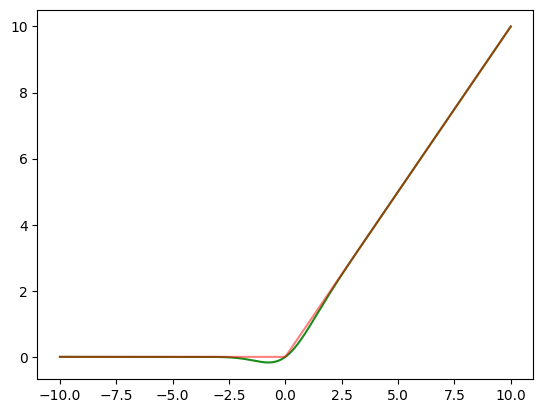

In [11]:
# Plotting GELU vs RELU
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

x = torch.tensor(torch.linspace(-10, 10, 500))
y_gelu, y_relu = gelu(x), relu(x)

plt.plot(x, y_gelu, color='green', alpha=0.9)
plt.plot(x, y_relu, color='red', alpha=0.5)

plt.show()

In [12]:
class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    emb_dim = cfg["emb_dim"]
    self.layers = nn.Sequential(
        nn.Linear(emb_dim, 4*emb_dim),
        GELU(),
        nn.Linear(4*emb_dim, emb_dim)
    )

  def forward(self, x):
    return self.layers(x)

### Skip or Residual connections

In [13]:
class ExampleDeepNN(nn.Module):
  def __init__(self, layer_sizes, use_shortcut):
    super().__init__()
    self.use_shortcut = use_shortcut
    layers = []
    for i in range(1, len(layer_sizes)):
      layers.append(
        nn.Sequential(
          nn.Linear(layer_sizes[i-1], layer_sizes[i]),
          GELU()
        )
      )
    self.layers = nn.Sequential(*layers)

  def forward(self, x):
    for layer in self.layers:
      layer_out = layer(x)

      if self.use_shortcut and x.shape == layer_out.shape:
        x = x + layer_out
      else:
        x = layer_out
    return x


In [14]:
def print_gradients(model, x):
  pred = model(x)
  y = torch.tensor([1.])

  loss = nn.MSELoss()
  loss = loss(pred, y)
  loss.backward()

  for name, param in model.named_parameters():
    print(f"{name} : {param.grad.abs().mean()}")

layer_sizes = [3, 3, 3, 3, 3, 1]
x = torch.tensor([1., 0., 1.])

model_without_shortcut = ExampleDeepNN(layer_sizes, use_shortcut=False)
model_with_shortcut = ExampleDeepNN(layer_sizes, use_shortcut=True)

print("======= WITHOUT SHORTCUT ==========")
print_gradients(model_without_shortcut, x)
print("======= WITH SHORTCUT ==========")
print_gradients(model_with_shortcut, x)

======= WITHOUT SHORTCUT ==========
layers.0.0.weight : 0.00037450960371643305
layers.0.0.bias : 0.0005617644055746496
layers.1.0.weight : 0.0003748164454009384
layers.1.0.bias : 0.0033132992684841156
layers.2.0.weight : 0.00159373227506876
layers.2.0.bias : 0.012172012589871883
layers.3.0.weight : 0.009930945001542568
layers.3.0.bias : 0.044340580701828
layers.4.0.weight : 0.10193073749542236
layers.4.0.bias : 1.1083672046661377
======= WITH SHORTCUT ==========
layers.0.0.weight : 0.046777043491601944
layers.0.0.bias : 0.07016556710004807
layers.1.0.weight : 0.06599541753530502
layers.1.0.bias : 0.0750858411192894
layers.2.0.weight : 0.06800946593284607
layers.2.0.bias : 0.05259477719664574
layers.3.0.weight : 0.052640002220869064
layers.3.0.bias : 0.035148292779922485
layers.4.0.weight : 0.43185552954673767
layers.4.0.bias : 0.28531330823898315


### Transformer Block

In [15]:
class MultiHeadAttention(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    d_in, d_out = cfg["emb_dim"], cfg["emb_dim"]
    context_length = cfg["context_length"]
    dropout = cfg["drop_rate"]
    num_heads = cfg["n_heads"]
    qkv_bias = cfg["qkv_bias"]

    assert(d_out % num_heads == 0)

    self.head_dim = d_out // num_heads
    self.num_heads = num_heads

    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer(
        'mask',
        torch.triu(torch.ones(context_length, context_length), diagonal=1)
    )
    self.projection = nn.Linear(d_out, d_out)

  def forward(self, x):
    # x -> [B, T, d_in]
    B, T, d_in = x.shape

    queries = self.W_query(x)
    keys = self.W_key(x)
    values = self.W_value(x)

    queries = queries.view(B, T, self.num_heads, self.head_dim) # [B, T, NH, HD]
    queries = queries.transpose(1, 2) # [B, NH, T, HD]
    keys = keys.view(B, T, self.num_heads, self.head_dim) # [B, T, NH, HD]
    keys = keys.transpose(1, 2) # [B, NH, T, HD]
    values = values.view(B, T, self.num_heads, self.head_dim)
    values = values.transpose(1, 2) # [B, NH, T, HD]

    attn_scores = queries @ keys.transpose(2, 3) # [B, NH, T, T]
    attn_scores.masked_fill_(self.mask.bool()[:T,:T], -torch.inf)
    attn_weights = torch.softmax(attn_scores/self.head_dim**0.5, dim=-1)
    attn_weights = self.dropout(attn_weights)

    context_vecs = attn_weights @ values # [B, NH, T, HD]
    context_vecs = context_vecs.transpose(1,2).reshape(B, T, -1)
    # Reshape instead of view because view needs contiguous
    # Alternative context_vecs.contiguous().view(B, T, -1)
    context_vecs = self.projection(context_vecs) # [B, T, d_out]
    return context_vecs

In [16]:
# Defining TransformerBlock since we have all the pieces now

class TransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.attn_block = MultiHeadAttention(cfg)
    self.ffwd = FeedForward(cfg)
    self.dropout = nn.Dropout(cfg["drop_rate"])
    self.layer_norm1 = LayerNorm(cfg["emb_dim"])
    self.layer_norm2 = LayerNorm(cfg["emb_dim"])

  def forward(self, x):
    shortcut = x
    x = self.layer_norm1(x)
    x = self.attn_block(x)
    x = self.dropout(x)
    x = x + shortcut

    shortcut = x
    x = self.layer_norm2(x)
    x = self.ffwd(x)
    x = self.dropout(x)
    x = x + shortcut

    return x

In [17]:
# Testing
torch.manual_seed(123)
x = torch.rand(2, 4, 768)
block = TransformerBlock(GPT_CONFIG_124M)
out = block(x)
out.shape

torch.Size([2, 4, 768])

### Final GPT Model

In [18]:
class GPTModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.token_embedding = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_embedding = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    self.layer_norm = LayerNorm(cfg["emb_dim"])
    self.transformer_blocks = nn.Sequential(
        *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
    )
    self.dropout = nn.Dropout(cfg["drop_rate"])
    self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=cfg["qkv_bias"])

  def forward(self, x):
    # x.shape [B, T]
    B, T = x.shape
    token_embd = self.token_embedding(x) # [B, T, E]  E -> emb_dim
    pos_embd = self.token_embedding(torch.arange(0, T)) # [T, E]
    x = token_embd + pos_embd # [T, E] broadcasted to [B, T, E] and then add
    x = self.dropout(x)
    x = self.transformer_blocks(x)
    x = self.layer_norm(x)
    x = self.out_head(x)
    return x


In [19]:
input

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

In [20]:
model = GPTModel(GPT_CONFIG_124M)
out = model(input)
out.shape, out

(torch.Size([2, 4, 50257]),
 tensor([[[ 0.0303,  0.6854, -0.0842,  ..., -0.4720,  0.6710, -0.3795],
          [-0.8880, -0.8683,  0.4521,  ..., -0.9626, -0.9780,  1.0213],
          [-0.6367, -0.2851, -0.7138,  ..., -0.6475,  0.4154, -0.1437],
          [ 0.0620,  0.0790,  1.5864,  ...,  0.1705, -0.2284, -0.1532]],
 
         [[-0.1229,  0.8624, -0.6401,  ...,  0.0303,  0.5281, -0.1817],
          [ 0.6421,  0.4208,  0.0093,  ...,  0.1463, -0.1550, -0.1836],
          [-0.0825, -0.3395, -1.0944,  ..., -1.0718,  0.2048, -0.1635],
          [-0.2767, -0.5722,  0.5824,  ...,  0.6264,  0.2662,  0.2344]]],
        grad_fn=<UnsafeViewBackward0>))

In [21]:
# Counting total parameters

total_params = sum([p.numel() for p in model.parameters()])
total_params/(1_000_000)

163.009536

#### EXERCISE 4.1

In [22]:
[name for name, p in model.transformer_blocks[0].named_parameters()]

['attn_block.W_query.weight',
 'attn_block.W_key.weight',
 'attn_block.W_value.weight',
 'attn_block.projection.weight',
 'attn_block.projection.bias',
 'ffwd.layers.0.weight',
 'ffwd.layers.0.bias',
 'ffwd.layers.2.weight',
 'ffwd.layers.2.bias',
 'layer_norm1.scale',
 'layer_norm1.shift',
 'layer_norm2.scale',
 'layer_norm2.shift']

In [23]:
ffwd_params = sum([p.numel() if 'ffwd' in name else 0 for name, p in model.transformer_blocks.named_parameters()])/1_000_000
mha_params = sum([p.numel() if 'attn' in name else 0 for name, p in model.transformer_blocks.named_parameters()])/1_000_000
token_embd_params = (GPT_CONFIG_124M["vocab_size"] * GPT_CONFIG_124M["emb_dim"])/1_000_000
pos_embd_params = (GPT_CONFIG_124M["context_length"] * GPT_CONFIG_124M["emb_dim"])/1_000_000

print(f"Feed Forward {ffwd_params}M  Attention {mha_params}M Token {token_embd_params}M Pos {pos_embd_params}M")

Feed Forward 56.669184M  Attention 28.320768M Token 38.597376M Pos 0.786432M


In [24]:
[name for name, p in model.transformer_blocks.named_parameters()]

['0.attn_block.W_query.weight',
 '0.attn_block.W_key.weight',
 '0.attn_block.W_value.weight',
 '0.attn_block.projection.weight',
 '0.attn_block.projection.bias',
 '0.ffwd.layers.0.weight',
 '0.ffwd.layers.0.bias',
 '0.ffwd.layers.2.weight',
 '0.ffwd.layers.2.bias',
 '0.layer_norm1.scale',
 '0.layer_norm1.shift',
 '0.layer_norm2.scale',
 '0.layer_norm2.shift',
 '1.attn_block.W_query.weight',
 '1.attn_block.W_key.weight',
 '1.attn_block.W_value.weight',
 '1.attn_block.projection.weight',
 '1.attn_block.projection.bias',
 '1.ffwd.layers.0.weight',
 '1.ffwd.layers.0.bias',
 '1.ffwd.layers.2.weight',
 '1.ffwd.layers.2.bias',
 '1.layer_norm1.scale',
 '1.layer_norm1.shift',
 '1.layer_norm2.scale',
 '1.layer_norm2.shift',
 '2.attn_block.W_query.weight',
 '2.attn_block.W_key.weight',
 '2.attn_block.W_value.weight',
 '2.attn_block.projection.weight',
 '2.attn_block.projection.bias',
 '2.ffwd.layers.0.weight',
 '2.ffwd.layers.0.bias',
 '2.ffwd.layers.2.weight',
 '2.ffwd.layers.2.bias',
 '2.layer_

### Generate text from model

In [56]:
def generate_text(input_str, max_tokens=50):
  model.eval()
  context_length = GPT_CONFIG_124M["context_length"]
  input_tokens = torch.tensor(tokenizer.encode(input_str))
  #print("Input", input_tokens, input_tokens.shape)
  input_batch = input_tokens.unsqueeze(0)
  #print("Before", input_batch.shape, input_batch)
  for _ in range(max_tokens):
    input_batch = input_batch[:, -context_length:]
    with torch.no_grad():
      logits = model(input_batch)
    probs = torch.softmax(logits[:,-1,:], dim=-1)
    #print(f"Probs: {probs.shape}")
    next = torch.argmax(probs, dim=-1, keepdim=True)
    #print(f"Next: {next} {next.shape}")
    input_batch = torch.cat([input_batch, next], dim=1)
    #print("After", input_batch, input_batch.shape)

  return tokenizer.decode(input_batch.squeeze(0).tolist())

generate_text("Every day is a new", max_tokens=5)

'Every day is a newHmm hugging issuer Motorsport 59'